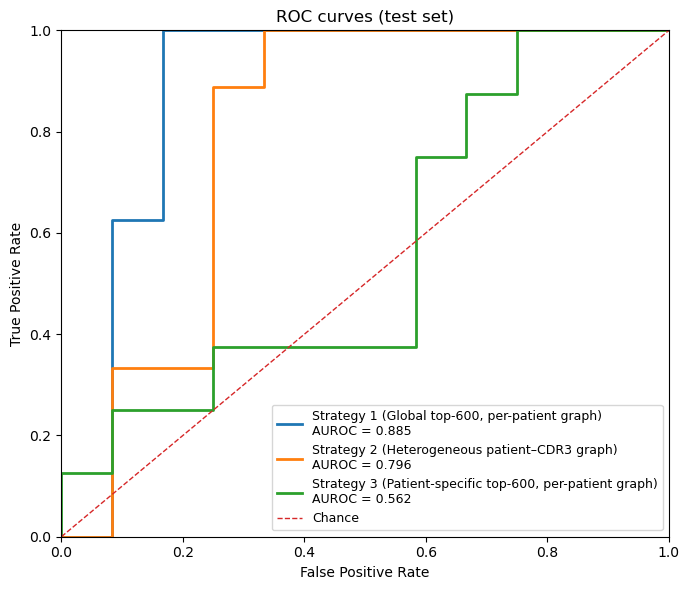

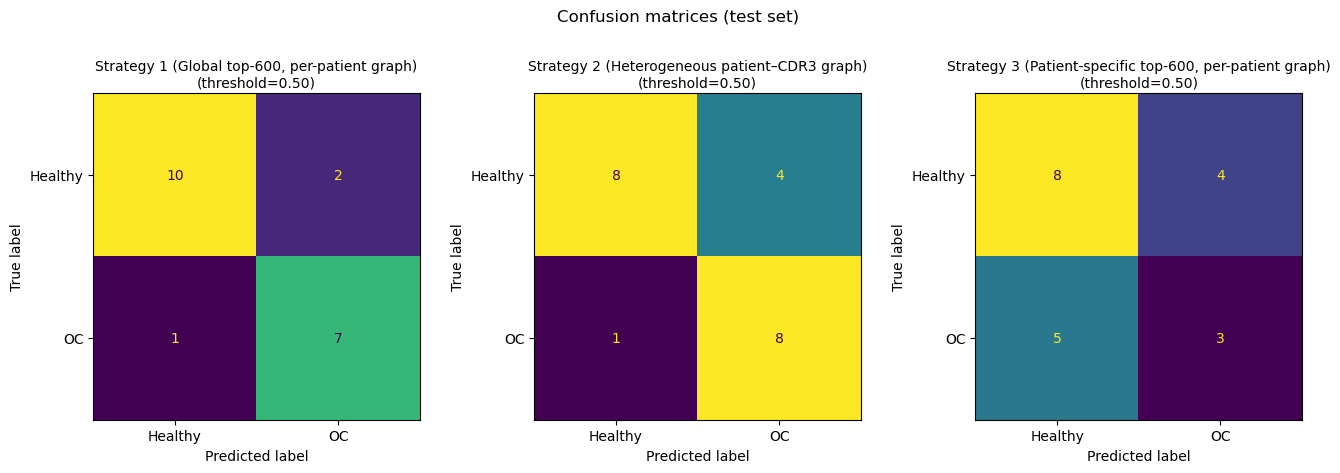

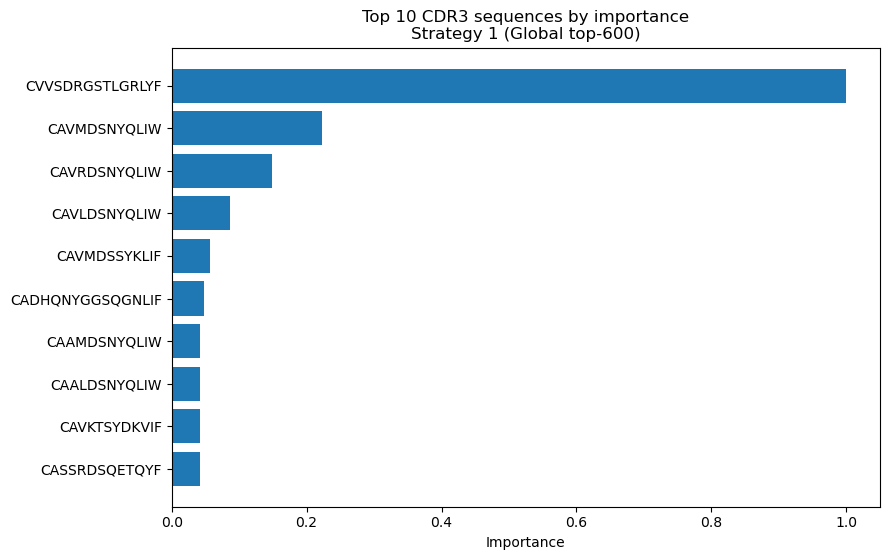

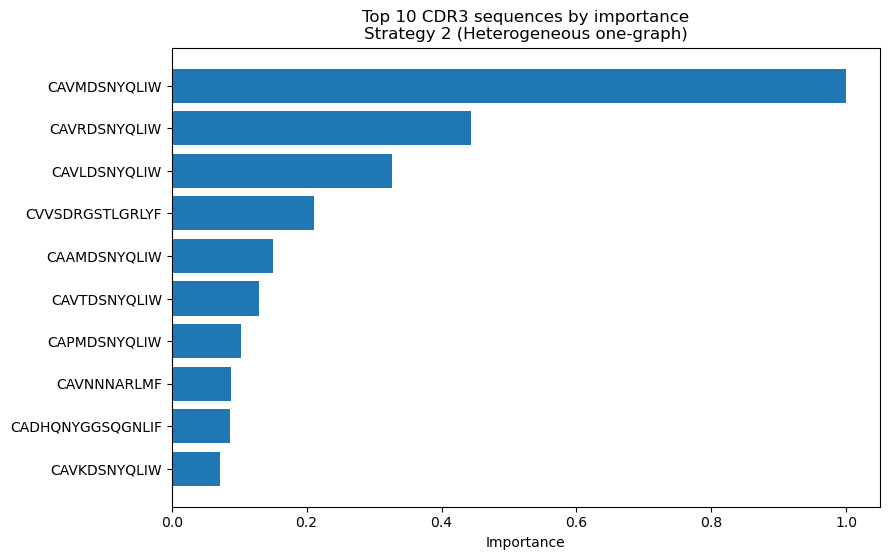

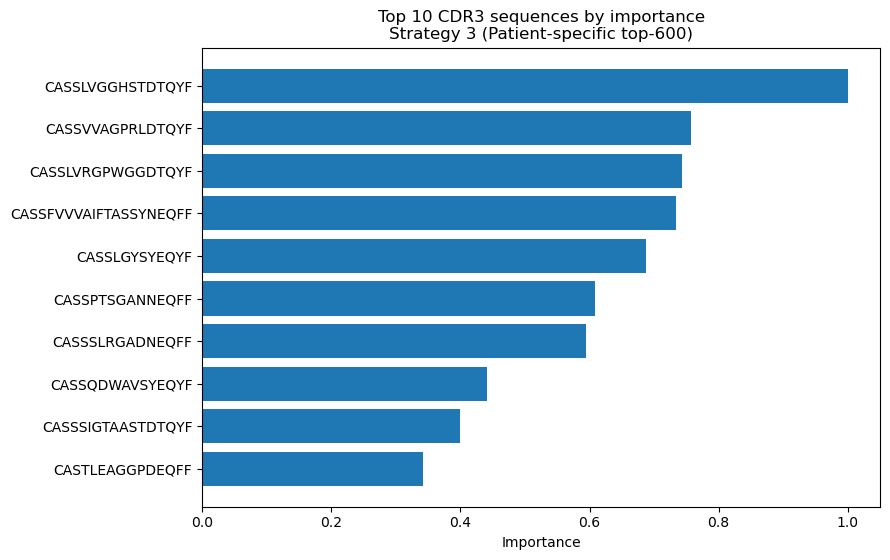

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ---------------------------
# File paths (your uploads)
# ---------------------------
PRED_FILES = {
    "Strategy 1 (Global top-600, per-patient graph)": "common_600/models/AB_0.08_True_True/test_predictions.csv",
    "Strategy 2 (Heterogeneous patient–CDR3 graph)": "one_graph_common_600/outputs/test_predictions.csv",
    "Strategy 3 (Patient-specific top-600, per-patient graph)": "top_600_per_patient/models/AB_0.08_True_True/test_predictions.csv",
}

IMP_FILES = {
    "Strategy 1 (Global top-600)": "common_600/models/AB_0.08_True_True/cdr3_importance.csv",
    "Strategy 2 (Heterogeneous one-graph)": "one_graph_common_600/outputs/cdr3_importance_global_mean.csv",
    "Strategy 3 (Patient-specific top-600)": "top_600_per_patient/models/AB_0.08_True_True/cdr3_importance.csv",
}

# ---------------------------
# Helpers
# ---------------------------
def load_predictions(path: str) -> pd.DataFrame:
    """
    Standardize prediction CSVs into columns:
      - patient_id
      - y_true (0/1)
      - y_score (probability for positive class)
      - y_pred  (0/1) if present; otherwise computed at 0.5
    """
    df = pd.read_csv(path).copy()

    # Identify columns across your files
    # Strategy 1 & 3: true_label, predicted_prob, predicted_label
    # Strategy 2: true_label, prob, pred_label
    if "true_label" not in df.columns:
        raise ValueError(f"{path}: missing 'true_label' column")

    if "predicted_prob" in df.columns:
        score_col = "predicted_prob"
    elif "prob" in df.columns:
        score_col = "prob"
    else:
        raise ValueError(f"{path}: missing probability column ('predicted_prob' or 'prob')")

    if "predicted_label" in df.columns:
        pred_col = "predicted_label"
    elif "pred_label" in df.columns:
        pred_col = "pred_label"
    else:
        pred_col = None

    out = pd.DataFrame({
        "patient_id": df["patient_id"] if "patient_id" in df.columns else np.arange(len(df)),
        "y_true": df["true_label"].astype(int),
        "y_score": df[score_col].astype(float),
    })

    if pred_col is not None:
        out["y_pred"] = df[pred_col].astype(int)
    else:
        out["y_pred"] = (out["y_score"] >= 0.5).astype(int)

    return out


def load_importance(path: str, normalize_01: bool = True) -> pd.DataFrame:
    """
    Standardize importance CSVs into:
      - cdr3
      - importance
    Optionally normalize importance to [0, 1] per file (min-max).
    """
    df = pd.read_csv(path).copy()

    if "cdr3_sequence" in df.columns:
        ccol = "cdr3_sequence"
    elif "CDR3_sequence" in df.columns:
        ccol = "CDR3_sequence"
    else:
        raise ValueError(f"{path}: missing CDR3 sequence column")

    if "importance_score" in df.columns:
        icol = "importance_score"
    elif "abs_contribution" in df.columns:
        icol = "abs_contribution"
    else:
        raise ValueError(f"{path}: missing importance column")

    out = pd.DataFrame({
        "cdr3": df[ccol].astype(str),
        "importance": df[icol].astype(float),
    })

    if normalize_01:
        mn = out["importance"].min()
        mx = out["importance"].max()
        if mx > mn:
            out["importance"] = (out["importance"] - mn) / (mx - mn)
        else:
            out["importance"] = 0.0  # כל הערכים זהים

    return out


# ---------------------------
# Figure 1: ROC curves (main)
# ---------------------------
def plot_roc_curves(pred_files: dict, savepath: str = None):
    plt.figure(figsize=(7, 6))

    for name, path in pred_files.items():
        d = load_predictions(path)
        y_true, y_score = d["y_true"].values, d["y_score"].values

        auc = roc_auc_score(y_true, y_score)
        fpr, tpr, _ = roc_curve(y_true, y_score)

        plt.plot(fpr, tpr, linewidth=2, label=f"{name}\nAUROC = {auc:.3f}")

    plt.plot([0, 1], [0, 1], linewidth=1, linestyle="--", label="Chance")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves (test set)")
    plt.legend(fontsize=9, loc="lower right")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()



# -------------------------------------------------
# Figure 4: Confusion matrices at a fixed threshold
# (report threshold explicitly in Results)
# -------------------------------------------------
def plot_confusion_matrices(pred_files: dict, threshold: float = 0.5, savepath: str = None):
    n = len(pred_files)
    fig, axes = plt.subplots(
        nrows=1, ncols=n,
        figsize=(5.2 * n, 4.8),
        constrained_layout=False
    )

    if n == 1:
        axes = [axes]

    for ax, (name, path) in zip(axes, pred_files.items()):
        d = load_predictions(path)
        y_true = d["y_true"].values
        y_pred = (d["y_score"].values >= threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "OC"])
        disp.plot(ax=ax, values_format="d", colorbar=False)

        # wrap=True עוזר למנוע חפיפות בכותרות ארוכות
        ax.set_title(f"{name}\n(threshold={threshold:.2f})", wrap=True, fontsize=10)

    # יותר מרווחים בין תתי-הגרפים + יותר מקום למעלה
    fig.subplots_adjust(top=0.82, wspace=0.35)

    # אם בא לך כותרת כללית לכל הפיגר:
    fig.suptitle("Confusion matrices (test set)", fontsize=12, y=0.98)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


# -----------------------------------------
# Figure 5: Top CDR3 importance (bar plot)
# -----------------------------------------
def plot_top_cdr3_importance(imp_files: dict, top_n: int = 20, savepath_prefix: str = None):
    """
    Makes one figure per model (horizontal bar plot).
    Saves as f"{savepath_prefix}_{i}.png" if prefix is given.
    """
    for i, (name, path) in enumerate(imp_files.items(), start=1):
        imp = load_importance(path).sort_values("importance", ascending=False).head(top_n)
        # reverse for a clean top-to-bottom plot
        imp = imp.iloc[::-1].reset_index(drop=True)

        plt.figure(figsize=(9, 0.35 * top_n + 2.2))
        plt.barh(imp["cdr3"], imp["importance"])
        plt.xlabel("Importance")
        plt.title(f"Top {top_n} CDR3 sequences by importance\n{name}")
        plt.tight_layout()

        if savepath_prefix:
            plt.savefig(f"{savepath_prefix}_{i}.png", dpi=300, bbox_inches="tight")
        plt.show()


# ---------------------------
# Run everything
# ---------------------------
if __name__ == "__main__":
    plot_roc_curves(PRED_FILES, savepath=None)
    plot_confusion_matrices(PRED_FILES, threshold=0.5, savepath=None)
    plot_top_cdr3_importance(IMP_FILES, top_n=10, savepath_prefix=None)

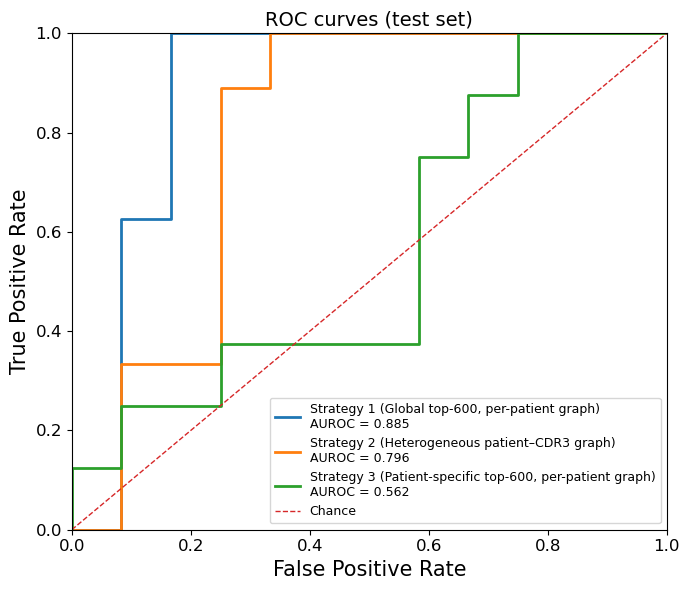

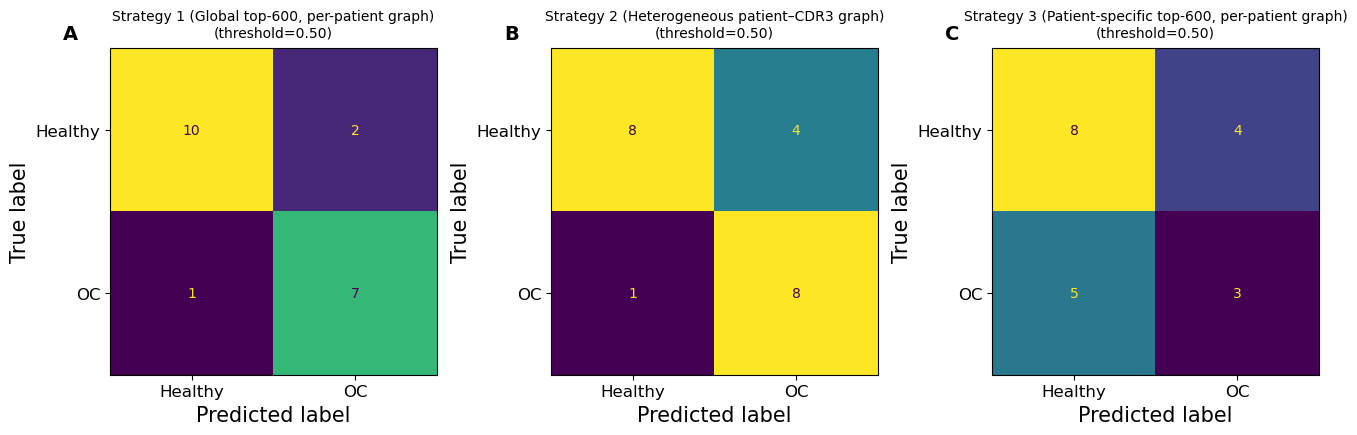

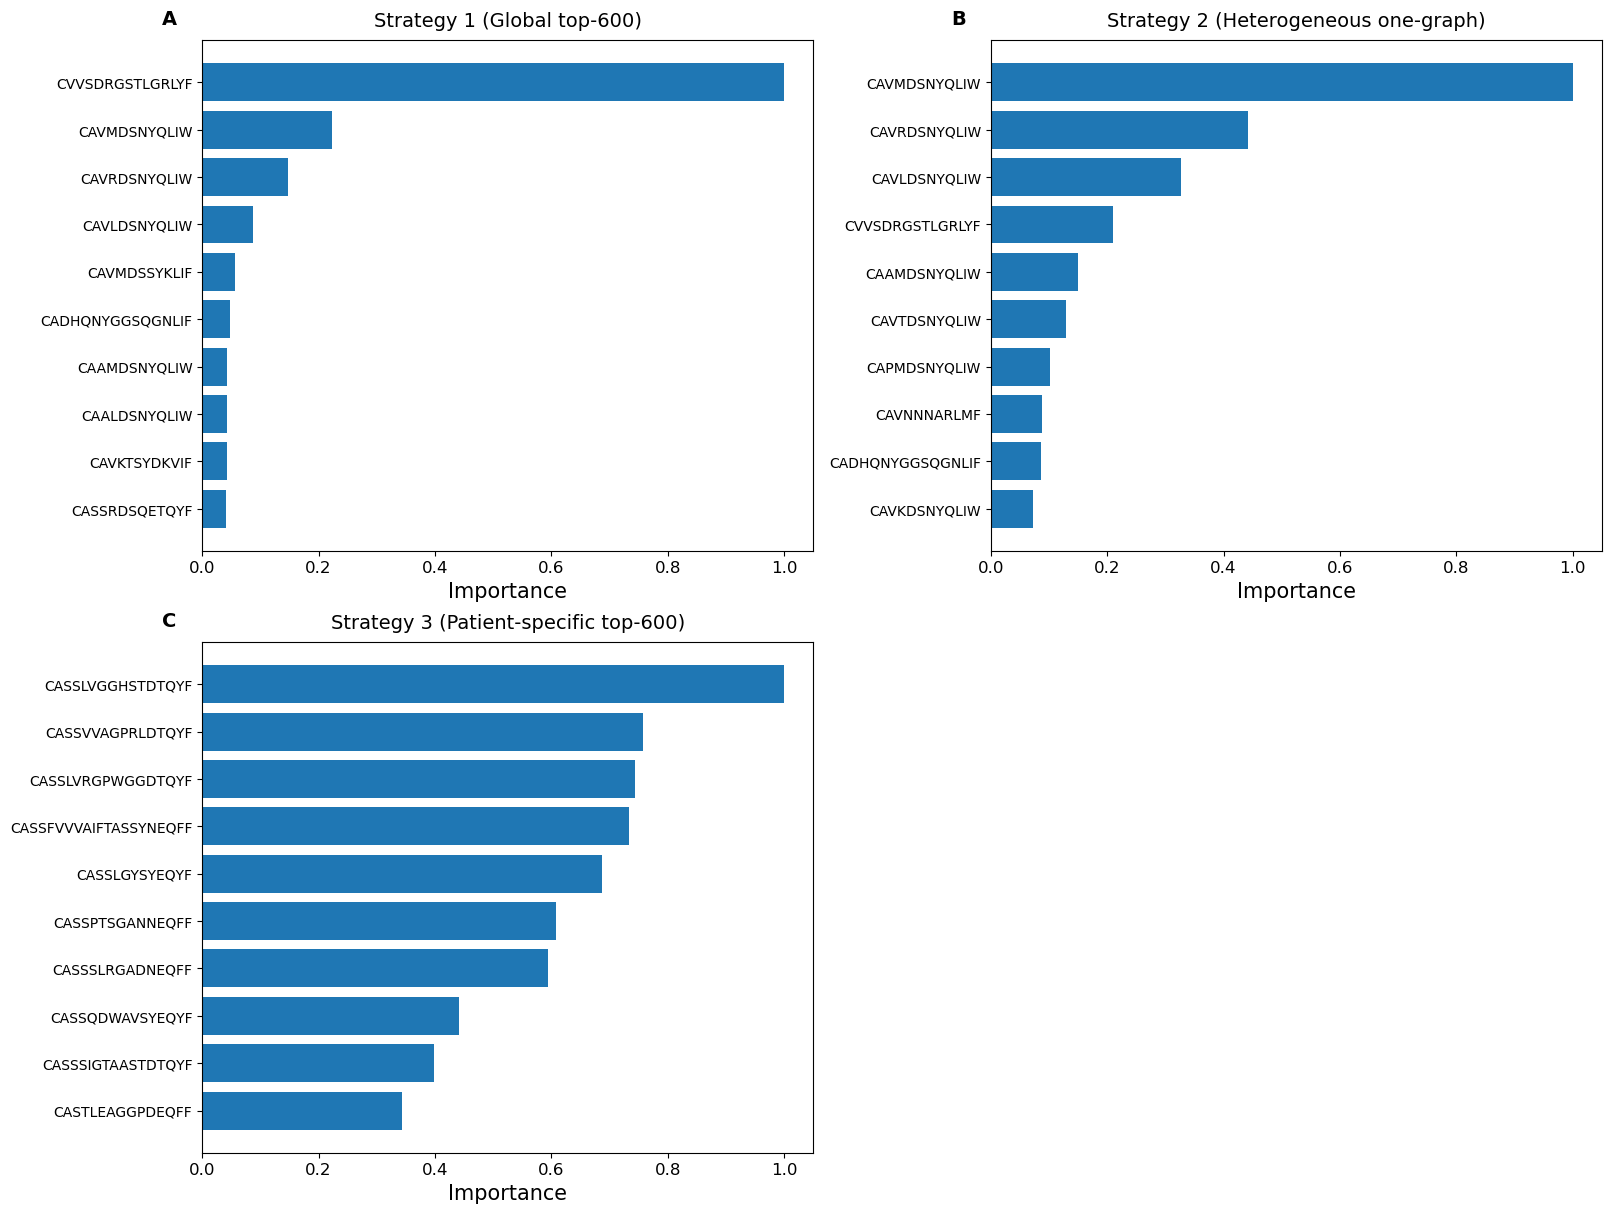

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ---------------------------
# Styling constants
# ---------------------------
AXIS_LABEL_FONTSIZE = 15
TICK_LABEL_FONTSIZE = 12
TITLE_FONTSIZE = 14
PANEL_LABEL_FONTSIZE = 14

def add_panel_label_outside(ax, label, x=-0.10, y=1.10):
    """
    Place panel label outside the axes (like in papers),
    using axes coordinates (can be <0 or >1).
    """
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False  # חשוב כדי שלא ייחתך מחוץ לציר
    )


def add_panel_label(ax, label, x=0.02, y=0.98):
    """
    Add panel label like 'A', 'B', ... at a consistent spot inside an axes.
    Coordinates are in axes fraction (0..1).
    """
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        fontweight="bold",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7)
    )

PANEL_LABEL_FONTSIZE = 14

def add_panel_labels_figure(fig, axes, labels, x_offset=-0.02, y_offset=0.02):
    """
    Place panel labels (A,B,C,...) in *figure coordinates* near each axes' top-left corner.
    This avoids overlapping with axes titles.
    """
    for ax, lab in zip(axes, labels):
        pos = ax.get_position()  # Bbox in figure coords (0..1)
        fig.text(
            pos.x0 + x_offset,
            pos.y1 + y_offset,
            lab,
            fontsize=PANEL_LABEL_FONTSIZE,
            fontweight="bold",
            ha="left",
            va="bottom"
        )

# ---------------------------
# Figure 1: ROC curves (main)
# ---------------------------
def plot_roc_curves(pred_files: dict, savepath: str = None):
    fig, ax = plt.subplots(figsize=(7, 6))

    for name, path in pred_files.items():
        d = load_predictions(path)
        y_true, y_score = d["y_true"].values, d["y_score"].values

        auc = roc_auc_score(y_true, y_score)
        fpr, tpr, _ = roc_curve(y_true, y_score)

        ax.plot(fpr, tpr, linewidth=2, label=f"{name}\nAUROC = {auc:.3f}")

    ax.plot([0, 1], [0, 1], linewidth=1, linestyle="--", label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Bigger axis titles (NEW)
    ax.set_xlabel("False Positive Rate", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("True Positive Rate", fontsize=AXIS_LABEL_FONTSIZE)

    # Bigger ticks (NEW)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)

    ax.set_title("ROC curves (test set)", fontsize=TITLE_FONTSIZE)
    ax.legend(fontsize=9, loc="lower right")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


# -------------------------------------------------
# Figure 4: Confusion matrices at a fixed threshold
# + add panel letters (NEW)
# -------------------------------------------------
def plot_confusion_matrices(pred_files: dict, threshold: float = 0.5, savepath: str = None):
    n = len(pred_files)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.8), constrained_layout=False)
    if n == 1:
        axes = [axes]

    letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:n]

    for ax, (name, path) in zip(axes, pred_files.items()):
        d = load_predictions(path)
        y_true = d["y_true"].values
        y_pred = (d["y_score"].values >= threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "OC"])
        disp.plot(ax=ax, values_format="d", colorbar=False)

        ax.set_xlabel("Predicted label", fontsize=AXIS_LABEL_FONTSIZE)
        ax.set_ylabel("True label", fontsize=AXIS_LABEL_FONTSIZE)
        ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)

        ax.set_title(f"{name}\n(threshold={threshold:.2f})", wrap=True, fontsize=10, pad=10)

    # מרווחים/לייאאוט קודם...
    fig.subplots_adjust(top=0.82, wspace=0.35)

    # ...ואז מוסיפים אותיות ברמת ה-figure (לא נוגעות בכותרות)
    add_panel_labels_figure(fig, axes, letters, x_offset=-0.03, y_offset=0.01)

    # fig.suptitle("Confusion matrices (test set)", fontsize=TITLE_FONTSIZE, y=0.98)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------------------
# Figure 5: Top CDR3 importance (bar plot)
# + add panel letters (NEW)
# -----------------------------------------
def plot_top_cdr3_importance(imp_files: dict, top_n: int = 20, savepath_prefix: str = None):
    letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    for i, (name, path) in enumerate(imp_files.items(), start=1):
        imp = load_importance(path).sort_values("importance", ascending=False).head(top_n)
        imp = imp.iloc[::-1].reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(9, 0.35 * top_n + 2.2))
        ax.barh(imp["cdr3"], imp["importance"])

        # הגדלת כותרות צירים + ticks
        ax.set_xlabel("Importance", fontsize=AXIS_LABEL_FONTSIZE)
        ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)

        ax.set_title(f"Top {top_n} CDR3 sequences by importance\n{name}", fontsize=TITLE_FONTSIZE)

        # האות מחוץ לגרף (כמו בדוגמה שלך)
        add_panel_label_outside(ax, letters[i - 1], x=-0.10, y=1.10)

        fig.tight_layout()
        if savepath_prefix:
            fig.savefig(f"{savepath_prefix}_{i}.png", dpi=300, bbox_inches="tight")
        plt.show()

import matplotlib.gridspec as gridspec

def plot_top_cdr3_importance_one_figure(
    imp_files: dict,
    top_n: int = 20,
    savepath: str = None
):
    items = list(imp_files.items())
    assert len(items) == 3, "This layout expects exactly 3 strategies."

    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    gs = gridspec.GridSpec(2, 2, figure=fig)

    # Layout:
    # [0,0] -> Strategy 1
    # [0,1] -> Strategy 2
    # [1,:] -> Strategy 3 (full width)

    axes = []
    axes.append(fig.add_subplot(gs[0, 0]))
    axes.append(fig.add_subplot(gs[0, 1]))
    axes.append(fig.add_subplot(gs[1, 0]))

    letters = ["A", "B", "C"]

    for idx, ((name, path), ax) in enumerate(zip(items, axes)):
        imp = load_importance(path).sort_values("importance", ascending=False).head(top_n)
        imp = imp.iloc[::-1].reset_index(drop=True)

        ax.barh(imp["cdr3"], imp["importance"])

        ax.set_xlabel("Importance", fontsize=AXIS_LABEL_FONTSIZE)
        ax.tick_params(axis="x", labelsize=TICK_LABEL_FONTSIZE)
        ax.tick_params(axis="y", labelsize=10)

        ax.set_title(name, fontsize=TITLE_FONTSIZE, pad=10)

    # fig.suptitle(f"Top {top_n} CDR3 sequences by importance", fontsize=TITLE_FONTSIZE)

    # חשוב — לחשב לייאאוט לפני מיקום אותיות
    fig.canvas.draw()
    add_panel_labels_figure(fig, axes, letters, x_offset=-0.025, y_offset=0.01)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

plot_roc_curves(PRED_FILES, savepath=None)
plot_confusion_matrices(PRED_FILES, threshold=0.5, savepath=None)
# plot_top_cdr3_importance(IMP_FILES, top_n=10, savepath_prefix=None)
plot_top_cdr3_importance_one_figure(IMP_FILES, top_n=10, savepath=None)